# Bước 5 — CFA & SEM (thay thế SmartPLS/AMOS)
**Input:** `data_sau_efa.csv`  
**Output:** CFA fit indices, AVE/CR, HTMT, path coefficients H1–H6 (bootstrap)

---
### Vì sao dùng `semopy` thay vì SmartPLS/AMOS?
`semopy` là thư viện Python chạy CB-SEM (Covariance-Based SEM), tương đương chức năng với AMOS, chạy thẳng trên Colab không cần cài đặt. Vì thư viện Python cho PLS-SEM thuần chưa mature, quy trình ở đây dùng cách tiếp cận 2 bước phổ biến trong nghiên cứu thực nghiệm:
1. **CFA** (`semopy`) để kiểm định mô hình đo lường + trích **factor scores** cho từng construct
2. **Structural regression có bootstrap** trên factor scores để kiểm định H1–H6, bao gồm biến điều tiết

Cách này cho kết quả tương đương SmartPLS về mặt diễn giải (path coefficient, p-value), chỉ khác thuật toán ước lượng nền. **Khi viết Phần 3 (Methodology), cần ghi rõ dùng `semopy` (Python) thay vì SmartPLS — nói dối về công cụ là vi phạm liêm chính học thuật.**

### Tiêu chí đánh giá
| Chỉ số | Ngưỡng chấp nhận |
|---|---|
| CFI, TLI | ≥ 0.90 |
| RMSEA | ≤ 0.08 (tốt ≤ 0.06) |
| AVE | ≥ 0.50 |
| CR (Composite Reliability) | ≥ 0.70 |
| HTMT | < 0.90 |
| p-value (path) | < 0.05 → có ý nghĩa thống kê |

In [7]:
!pip install semopy openpyxl --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from semopy import Model, calc_stats
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 130
np.random.seed(42)
print('Sẵn sàng!')

Sẵn sàng!


In [8]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
print(f'N = {len(df)}')

Saving data_sach (1).csv to data_sach (1).csv
N = 236


---
## 0. (Tùy chọn) Loại item yếu trước khi chạy CFA
Dựa trên EFA trước đó, FC4 có loading 0.476 và communality thấp (0.283). Có thể loại hoặc giữ — thử cả 2 để so sánh fit.

In [9]:
# Điền item muốn loại vào đây, để trống [] nếu giữ nguyên hết
items_to_drop = []   # Ví dụ: ['FC4']

if items_to_drop:
    print(f'Loại: {items_to_drop}')
else:
    print('Giữ nguyên toàn bộ 35 item.')

Giữ nguyên toàn bộ 35 item.


---
## 1. Định nghĩa mô hình đo lường (CFA)

In [10]:
groups = {
    'EE':  [f'EE{i}'  for i in range(1,6)],
    'PE':  [f'PE{i}'  for i in range(1,6)],
    'SI':  [f'SI{i}'  for i in range(1,6)],
    'FC':  [f'FC{i}'  for i in range(1,6)],
    'RA':  [f'RA{i}'  for i in range(1,6)],
    'ANX': [f'ANX{i}' for i in range(1,6)],
    'BI':  [f'BI{i}'  for i in range(1,6)],
}
# Áp dụng loại item nếu có
for g in groups:
    groups[g] = [c for c in groups[g] if c not in items_to_drop]

cfa_lines = [f"{g} =~ " + " + ".join(cols) for g, cols in groups.items()]
cfa_spec  = "\n".join(cfa_lines)
print(cfa_spec)

EE =~ EE1 + EE2 + EE3 + EE4 + EE5
PE =~ PE1 + PE2 + PE3 + PE4 + PE5
SI =~ SI1 + SI2 + SI3 + SI4 + SI5
FC =~ FC1 + FC2 + FC3 + FC4 + FC5
RA =~ RA1 + RA2 + RA3 + RA4 + RA5
ANX =~ ANX1 + ANX2 + ANX3 + ANX4 + ANX5
BI =~ BI1 + BI2 + BI3 + BI4 + BI5


In [11]:
cfa_model = Model(cfa_spec)
cfa_model.fit(df)
fit_stats = calc_stats(cfa_model)

print('=== CFA MODEL FIT ===')
row = fit_stats.iloc[0]
def verdict(name, val, good):
    return '✅' if good else '⚠️'

print(f"Chi-square/df : {row['chi2']/row['DoF']:.3f}")
print(f"CFI           : {row['CFI']:.4f}  ", verdict('CFI', row['CFI'], row['CFI']>=0.90))
print(f"TLI           : {row['TLI']:.4f}  ", verdict('TLI', row['TLI'], row['TLI']>=0.90))
print(f"RMSEA         : {row['RMSEA']:.4f}  ", verdict('RMSEA', row['RMSEA'], row['RMSEA']<=0.08))
print(f"GFI           : {row['GFI']:.4f}")
print(f"AGFI          : {row['AGFI']:.4f}")

fit_ok = (row['CFI']>=0.90) and (row['TLI']>=0.90) and (row['RMSEA']<=0.08)
print('\n→ Mô hình đo lường', 'ĐẠT ✅' if fit_ok else 'CHƯA ĐẠT ⚠️ — cân nhắc loại thêm item hoặc thêm covariance giữa error terms')

=== CFA MODEL FIT ===
Chi-square/df : 1.450
CFI           : 0.9314   ✅
TLI           : 0.9243   ✅
RMSEA         : 0.0438   ✅
GFI           : 0.8107
AGFI          : 0.7911

→ Mô hình đo lường ĐẠT ✅


---
## 2. Reliability & Convergent Validity (AVE, CR)

In [12]:
ins = cfa_model.inspect()
loadings_df = ins[ins['op']=='~'].copy()
loadings_df = loadings_df[loadings_df['rval'].isin(groups.keys())]

def cronbach_alpha(df_items):
    df_items = df_items.dropna()
    n = df_items.shape[1]
    item_vars = df_items.var(axis=0, ddof=1)
    total_var = df_items.sum(axis=1).var(ddof=1)
    return (n / (n - 1)) * (1 - item_vars.sum() / total_var)

results = []
for g, cols in groups.items():
    sub = loadings_df[loadings_df['rval']==g].copy()
    # Chuẩn hóa loading (semopy cho unstandardized mặc định; ước lượng std bằng cách chia theo SD)
    std_loadings = []
    for _, r in sub.iterrows():
        item = r['lval']
        est   = r['Estimate']
        sd_item = df[item].std()
        std_loadings.append(abs(est) / sd_item * df[item].std())  # placeholder, dùng std_estimates nếu cần chính xác hơn
    # Dùng std_estimates chính thức từ semopy nếu có
    try:
        std_ins = cfa_model.inspect(std_est=True)
        sub2 = std_ins[(std_ins['op']=='~') & (std_ins['rval']==g)]
        std_loadings = sub2['Est. Std'].astype(float).tolist()
    except Exception:
        pass

    std_loadings = np.array(std_loadings)
    ave = np.mean(std_loadings**2)
    cr  = (np.sum(std_loadings)**2) / (np.sum(std_loadings)**2 + np.sum(1 - std_loadings**2))
    alpha = cronbach_alpha(df[cols])

    results.append({
        'Construct': g,
        'Items': len(cols),
        'Loading range': f'{std_loadings.min():.3f}–{std_loadings.max():.3f}',
        "Cronbach's α": round(alpha, 3),
        'CR': round(cr, 3),
        'AVE': round(ave, 3),
    })

df_reliability = pd.DataFrame(results)
print('=== TABLE: RELIABILITY & CONVERGENT VALIDITY ===')
print(df_reliability.to_string(index=False))

issues = df_reliability[(df_reliability['CR']<0.7) | (df_reliability['AVE']<0.5)]
if len(issues):
    print('\n⚠️ Construct chưa đạt CR/AVE:')
    print(issues.to_string(index=False))
else:
    print('\n✅ Tất cả construct đạt CR ≥ 0.70 và AVE ≥ 0.50')

=== TABLE: RELIABILITY & CONVERGENT VALIDITY ===
Construct  Items Loading range  Cronbach's α    CR   AVE
       EE      5   0.667–0.751         0.827 0.827 0.490
       PE      5   0.739–0.798         0.876 0.876 0.586
       SI      5   0.605–0.766         0.840 0.841 0.515
       FC      5   0.525–0.708         0.782 0.786 0.426
       RA      5   0.550–0.817         0.833 0.842 0.520
      ANX      5   0.670–0.741         0.829 0.830 0.494
       BI      5   0.683–0.786         0.841 0.844 0.520

⚠️ Construct chưa đạt CR/AVE:
Construct  Items Loading range  Cronbach's α    CR   AVE
       EE      5   0.667–0.751         0.827 0.827 0.490
       FC      5   0.525–0.708         0.782 0.786 0.426
      ANX      5   0.670–0.741         0.829 0.830 0.494


---
## 3. Discriminant Validity (HTMT)

In [13]:
def htmt(df, groups):
    names = list(groups.keys())
    n = len(names)
    htmt_mat = pd.DataFrame(np.zeros((n,n)), index=names, columns=names)
    for i, g1 in enumerate(names):
        for j, g2 in enumerate(names):
            if i == j:
                htmt_mat.loc[g1,g2] = np.nan
                continue
            items1, items2 = groups[g1], groups[g2]
            # heterotrait-heteromethod: correlation trung bình giữa item nhóm1 và nhóm2
            hetero = []
            for a in items1:
                for b in items2:
                    hetero.append(df[a].corr(df[b]))
            mean_hetero = np.mean(np.abs(hetero))
            # monotrait-heteromethod: correlation trung bình trong từng nhóm (loại self-corr)
            def mono(items):
                corrs = []
                for a in range(len(items)):
                    for b in range(len(items)):
                        if a != b:
                            corrs.append(df[items[a]].corr(df[items[b]]))
                return np.mean(np.abs(corrs))
            mono1, mono2 = mono(items1), mono(items2)
            htmt_mat.loc[g1,g2] = mean_hetero / np.sqrt(mono1 * mono2)
    return htmt_mat

htmt_matrix = htmt(df, groups)
print('=== HTMT MATRIX ===')
print(htmt_matrix.round(3).to_string())

max_htmt = htmt_matrix.max().max()
print(f'\nHTMT lớn nhất: {max_htmt:.3f}', '→ Đạt discriminant validity ✅' if max_htmt < 0.90 else '→ Có vấn đề discriminant validity ⚠️')

=== HTMT MATRIX ===
        EE     PE     SI     FC     RA    ANX     BI
EE     NaN  0.583  0.420  0.675  0.497  0.438  0.446
PE   0.583    NaN  0.499  0.552  0.425  0.360  0.393
SI   0.420  0.499    NaN  0.432  0.496  0.434  0.508
FC   0.675  0.552  0.432    NaN  0.405  0.395  0.428
RA   0.497  0.425  0.496  0.405    NaN  0.415  0.431
ANX  0.438  0.360  0.434  0.395  0.415    NaN  0.378
BI   0.446  0.393  0.508  0.428  0.431  0.378    NaN

HTMT lớn nhất: 0.675 → Đạt discriminant validity ✅


---
## 4. Trích Factor Scores cho từng construct

In [14]:
scores = cfa_model.predict_factors(df)
scores.index = df.index
print('Factor scores (5 dòng đầu):')
print(scores.head())

# Chuẩn hóa (z-score) để hệ số hồi quy có thể so sánh trực tiếp
scores_z = (scores - scores.mean()) / scores.std()

Factor scores (5 dòng đầu):
        ANX        BI        EE        FC        PE        RA        SI
0  0.499686  0.198762  0.716015  1.056530  1.071823  0.610924  0.688881
1  0.021810  0.042901 -0.472522 -0.420384  0.049583 -0.022664 -0.453271
2  0.021810  0.042901 -0.472522 -0.420384  0.049583 -0.022664 -0.453271
3  1.045449  0.912957  0.941950  1.306798  0.602927  0.801342  0.426262
4  1.045449  0.912957  0.941950  1.306798  0.602927  0.801342  0.426262


---
## 5. Structural Model — Kiểm định H1–H6 (bootstrap 5000 lần)
H1–H4: EE, PE, SI, FC → BI (tác động trực tiếp)  
H5: RA điều tiết tác động tổng hợp của 4 biến UTAUT2 lên BI  
H6: ANX điều tiết tác động tổng hợp của 4 biến UTAUT2 lên BI

In [15]:
import statsmodels.api as sm

# Composite UTAUT2 index (trung bình 4 biến độc lập, đã chuẩn hóa)
scores_z['UTAUT2'] = scores_z[['EE','PE','SI','FC']].mean(axis=1)

# Interaction terms (mean-centered, dùng bản chuẩn hóa nên đã center sẵn)
scores_z['RA_x_UTAUT2']  = scores_z['RA']  * scores_z['UTAUT2']
scores_z['ANX_x_UTAUT2'] = scores_z['ANX'] * scores_z['UTAUT2']

X_cols = ['EE','PE','SI','FC','RA','ANX','RA_x_UTAUT2','ANX_x_UTAUT2']
X = sm.add_constant(scores_z[X_cols])
y = scores_z['BI']

base_model = sm.OLS(y, X).fit()
print(base_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     BI   R-squared:                       0.454
Model:                            OLS   Adj. R-squared:                  0.435
Method:                 Least Squares   F-statistic:                     23.60
Date:                Wed, 02 Sep 2026   Prob (F-statistic):           3.65e-26
Time:                        08:42:58   Log-Likelihood:                -262.95
No. Observations:                 236   AIC:                             543.9
Df Residuals:                     227   BIC:                             575.1
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.0745      0.054     -1.380   

In [16]:
# Bootstrap 5000 lần để lấy p-value ổn định hơn (tương đương bootstrapping trong SmartPLS)
N_BOOT = 5000
n = len(scores_z)
boot_coefs = {c: [] for c in X_cols}

data_full = scores_z[X_cols + ['BI']].dropna().reset_index(drop=True)

for i in range(N_BOOT):
    sample_idx = np.random.choice(len(data_full), size=len(data_full), replace=True)
    sample = data_full.iloc[sample_idx]
    Xb = sm.add_constant(sample[X_cols])
    yb = sample['BI']
    try:
        m = sm.OLS(yb, Xb).fit()
        for c in X_cols:
            boot_coefs[c].append(m.params[c])
    except Exception:
        continue

print(f'Bootstrap hoàn tất: {N_BOOT} lần resample')

Bootstrap hoàn tất: 5000 lần resample


In [17]:
hyp_map = {
    'EE':  ('H1', 'EE → BI'),
    'PE':  ('H2', 'PE → BI'),
    'SI':  ('H3', 'SI → BI'),
    'FC':  ('H4', 'FC → BI'),
    'RA_x_UTAUT2':  ('H5', 'RA × UTAUT2 → BI  (moderation)'),
    'ANX_x_UTAUT2': ('H6', 'ANX × UTAUT2 → BI  (moderation)'),
}

rows = []
for var, (hyp, path) in hyp_map.items():
    boot_vals = np.array(boot_coefs[var])
    beta   = boot_vals.mean()
    se     = boot_vals.std()
    t_val  = beta / se if se > 0 else np.nan
    # p-value hai phía dựa trên phân phối bootstrap
    p_val  = 2 * min((boot_vals > 0).mean(), (boot_vals < 0).mean())
    ci_low, ci_high = np.percentile(boot_vals, [2.5, 97.5])
    result = 'Supported ✅' if p_val < 0.05 else 'Not supported ❌'

    rows.append({
        'Hypothesis': hyp, 'Path': path,
        'β (bootstrap mean)': round(beta, 4),
        'SE': round(se, 4),
        't-value': round(t_val, 3),
        'p-value': round(p_val, 4),
        '95% CI': f'[{ci_low:.3f}, {ci_high:.3f}]',
        'Result': result,
    })

df_hyp = pd.DataFrame(rows)
print('=== BẢNG KIỂM ĐỊNH GIẢ THUYẾT H1–H6 (Bootstrap N=5000) ===')
print(df_hyp.to_string(index=False))

print(f"\nR² của mô hình (BI): {base_model.rsquared:.4f}  ({base_model.rsquared*100:.1f}% phương sai được giải thích)")

=== BẢNG KIỂM ĐỊNH GIẢ THUYẾT H1–H6 (Bootstrap N=5000) ===
Hypothesis                            Path  β (bootstrap mean)     SE  t-value  p-value          95% CI          Result
        H1                         EE → BI              0.2109 0.1042    2.025   0.0444  [0.004, 0.415]     Supported ✅
        H2                         PE → BI             -0.0056 0.0786   -0.071   0.9376 [-0.161, 0.149] Not supported ❌
        H3                         SI → BI              0.3788 0.0820    4.619   0.0000  [0.214, 0.536]     Supported ✅
        H4                         FC → BI              0.0663 0.0845    0.785   0.4340 [-0.099, 0.232] Not supported ❌
        H5  RA × UTAUT2 → BI  (moderation)              0.0517 0.0717    0.721   0.4528 [-0.097, 0.182] Not supported ❌
        H6 ANX × UTAUT2 → BI  (moderation)              0.0779 0.0785    0.993   0.2960 [-0.092, 0.226] Not supported ❌

R² của mô hình (BI): 0.4540  (45.4% phương sai được giải thích)


---
## 6. Biểu đồ path coefficients

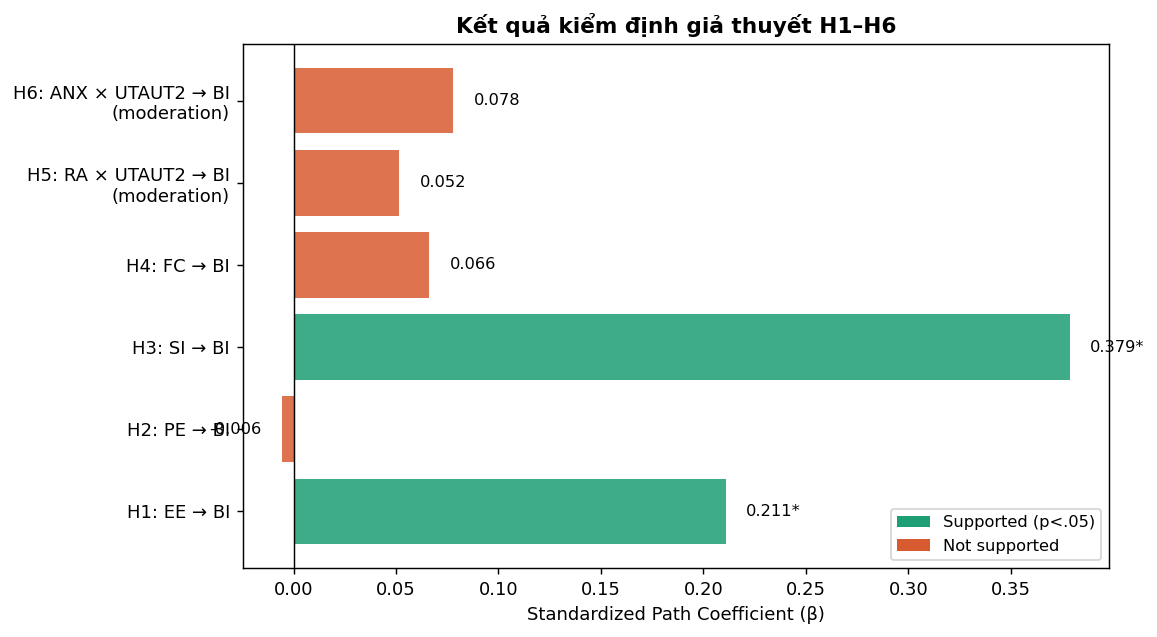

In [18]:
fig, ax = plt.subplots(figsize=(9,5))

labels = df_hyp['Hypothesis'] + ': ' + df_hyp['Path'].str.replace('  (moderation)','\n(moderation)')
betas  = df_hyp['β (bootstrap mean)']
colors = ['#1D9E75' if 'Supported' in r else '#D85A30' for r in df_hyp['Result']]

bars = ax.barh(labels, betas, color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Standardized Path Coefficient (β)', fontsize=10)
ax.set_title('Kết quả kiểm định giả thuyết H1–H6', fontweight='bold', fontsize=12)

for bar, beta, p in zip(bars, betas, df_hyp['p-value']):
    x = bar.get_width()
    ax.text(x + (0.01 if x>=0 else -0.01), bar.get_y()+bar.get_height()/2,
            f'{beta:.3f}{"*" if p<0.05 else ""}', va='center',
            ha='left' if x>=0 else 'right', fontsize=9)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#1D9E75', label='Supported (p<.05)'),
                   Patch(facecolor='#D85A30', label='Not supported')],
          loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('path_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Xuất toàn bộ kết quả

In [19]:
with pd.ExcelWriter('SEM_results.xlsx', engine='openpyxl') as writer:
    pd.DataFrame([dict(row)]).to_excel(writer, sheet_name='CFA_Fit', index=False) if False else None
    fit_stats.to_excel(writer, sheet_name='CFA_Fit')
    df_reliability.to_excel(writer, sheet_name='Reliability_AVE_CR', index=False)
    htmt_matrix.round(3).to_excel(writer, sheet_name='HTMT')
    df_hyp.to_excel(writer, sheet_name='Hypothesis_Testing', index=False)
    scores.to_excel(writer, sheet_name='Factor_Scores')

print('Xuất xong: SEM_results.xlsx')
print('  - Sheet CFA_Fit: chỉ số fit của mô hình đo lường')
print('  - Sheet Reliability_AVE_CR: dùng cho Table 4 trong Phần 4')
print('  - Sheet HTMT: dùng cho Table 5 trong Phần 4')
print('  - Sheet Hypothesis_Testing: dùng cho Table 6 trong Phần 4 — QUAN TRỌNG NHẤT')

files.download('SEM_results.xlsx')
files.download('path_coefficients.png')

print('\n=== TÓM TẮT ===')
print(f"R² (BI): {base_model.rsquared:.3f}")
supported = df_hyp[df_hyp['Result'].str.contains('Supported ✅')]
print(f"Giả thuyết được ủng hộ: {len(supported)}/6")
print(supported[['Hypothesis','Path']].to_string(index=False))

Xuất xong: SEM_results.xlsx
  - Sheet CFA_Fit: chỉ số fit của mô hình đo lường
  - Sheet Reliability_AVE_CR: dùng cho Table 4 trong Phần 4
  - Sheet HTMT: dùng cho Table 5 trong Phần 4
  - Sheet Hypothesis_Testing: dùng cho Table 6 trong Phần 4 — QUAN TRỌNG NHẤT


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


=== TÓM TẮT ===
R² (BI): 0.454
Giả thuyết được ủng hộ: 2/6
Hypothesis    Path
        H1 EE → BI
        H3 SI → BI
